{{ prolog }}

# MESMER-M workflow for multiple scenarios

Training monthly local temperature from yearly local temperature for multiple scenarios and ensemble members. We use an example data set on a coarse grid. This roughly follows the approach outlined in Nath et al. ([2022](https://esd.copernicus.org/articles/13/851/2022/)).


MESMER-M trains the local monthly temperature using the local annual temperature (i.e. the temperature from the same grid point) as forcing. This is different from MESMER which uses global mean values as predictors for where local annual mean temperatures. Training MESMER-M consists of 4 steps:

* **harmonic model**: fit the seasonal cycle with a harmonic model
* **power transformer**: make the resulting residuals more normal by using a Yeo-Johnson transformation
* **cyclo-stationary AR(1) process**: the monthly residuals are assumed to follow a cyclo-stationary AR(1) process, where one months value depends on the previous one
* **local variability**: estimate parameters needed to generate local variability

This example can be extended to more scenarios, ensemble members and higher resolution data. See also the MESMER-M calibration and emulation tests in *tests/integration/*.

In [58]:
import pathlib

import filefisher
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import xarray as xr

import mesmer

## Configuration

In [59]:
# target model
model = "IPSL-CM6A-LR"

# scenarios used for training
scenarios = ["ssp126", "ssp585"]

# gridcells considered as land
THRESHOLD_LAND = 1 / 3

# reference period
REFERENCE_PERIOD = slice("1850", "1900")

# localisation radius for covariance matrix
LOCALISATION_RADII = list(range(7_500, 12_501, 500))

# mesmer provides example data under "./data/cmip6-ng"
cmip6_data_path = mesmer.example_data.cmip6_ng_path(relative=True)

# mesmer-m downscales annual temperature to
# monthly resolution

# variable, shared for input and output
variable = "tas"

# spatial resolution, shared for input and output
spatial_resolution = "g025"

# targeted temporal resolution
temporal_resolution_target = "mon"

# initial temporal resolution
temporal_resolution_initial = "ann"

## Load Data 

We load monthly and annual mean temperatures using the library [*filefisher*](https://github.com/mpytools/filefisher)


In [60]:
CMIP_FILEFINDER = filefisher.FileFinder(
    path_pattern=cmip6_data_path / "{variable}/{time_res}/{resolution}",
    file_pattern="{variable}_{time_res}_{model}_{scenario}_{member}_{resolution}.nc",
)

We search for the intial (annaul) data for ssp126 and ssp585 as well as the corresponding historical data:

In [61]:
fc_scens_y = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario=scenarios,
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_initial,
)

# get the historical members that
# are also in the future scenarios,
# but only once
unique_scen_members_y = fc_scens_y.df.member.unique()

fc_hist_y = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario="historical",
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_initial,
    member=unique_scen_members_y,
)

fc_all_y = fc_hist_y.concat(fc_scens_y)
fc_all_y.df

,variable,time_res,resolution,model,scenario,member
path,,,,,,
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_historical_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,historical,r1i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_historical_r2i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,historical,r2i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_ssp126_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,ssp126,r1i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_ssp585_r1i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,ssp585,r1i1p1f1
../data/cmip6-ng/tas/ann/g025/tas_ann_IPSL-CM6A-LR_ssp585_r2i1p1f1_g025.nc,tas,ann,g025,IPSL-CM6A-LR,ssp585,r2i1p1f1


Similarly, we search for the target (monthly) data for ssp126 and ssp585 as well as the corresponding historical data:

In [62]:
fc_scens_m = CMIP_FILEFINDER.find_files(
    variable=variable,
    scenario=scenarios,
    model=model,
    resolution=spatial_resolution,
    time_res=temporal_resolution_target,
)

# get the historical members that are also in the future scenarios, but only once
unique_scen_members_m = fc_scens_y.df.member.unique()

fc_hist_m = CMIP_FILEFINDER.find_files(
    variable="tas",
    scenario="historical",
    model=model,
    resolution="g025",
    time_res="mon",
    member=unique_scen_members_m,
)

fc_all_m = fc_hist_m.concat(fc_scens_m)
fc_all_m.df

,variable,time_res,resolution,model,scenario,member
path,,,,,,
../data/cmip6-ng/tas/mon/g025/tas_mon_IPSL-CM6A-LR_historical_r1i1p1f1_g025.nc,tas,mon,g025,IPSL-CM6A-LR,historical,r1i1p1f1
../data/cmip6-ng/tas/mon/g025/tas_mon_IPSL-CM6A-LR_historical_r2i1p1f1_g025.nc,tas,mon,g025,IPSL-CM6A-LR,historical,r2i1p1f1
../data/cmip6-ng/tas/mon/g025/tas_mon_IPSL-CM6A-LR_ssp126_r1i1p1f1_g025.nc,tas,mon,g025,IPSL-CM6A-LR,ssp126,r1i1p1f1
../data/cmip6-ng/tas/mon/g025/tas_mon_IPSL-CM6A-LR_ssp585_r1i1p1f1_g025.nc,tas,mon,g025,IPSL-CM6A-LR,ssp585,r1i1p1f1
../data/cmip6-ng/tas/mon/g025/tas_mon_IPSL-CM6A-LR_ssp585_r2i1p1f1_g025.nc,tas,mon,g025,IPSL-CM6A-LR,ssp585,r2i1p1f1


This found 1 ensemble member for SSP1-2.6 and two for SSP5-8.5 and the corresponding ones in the historical scenario.

Now we load all the files we found into a ``DataTree``, a data structure provided by [xarray](https://docs.xarray.dev/en/stable/index.html). It is a container to hold xarray `Dataset` objects that are not alignable. This is useful for us since we have historical and future data, which have different time coordinates. Moreover, the scenarios may also have different numbers of members (as e.g., SSP1-2.6, which only has one). Thus, we store the data of each scenario in a `Dataset` with all its ensemble members along a `member` dimension. Then we store all the scenario datasets in one `DataTree` node. The `DataTree` allows us to perform computations on each of the scenarios separately.

We define a helper function to load the data from the cmip6_ng example data repository:

In [63]:
def load_data(filecontainer):

    out = xr.DataTree()

    scenarios = filecontainer.df.scenario.unique().tolist()

    # load data for each scenario
    for scen in scenarios:
        files = filecontainer.search(scenario=scen)

        # load all members for a scenario
        members = []
        for fN, meta in files.items():
            time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
            ds = xr.open_dataset(fN, decode_times=time_coder)
            # drop unnecessary variables
            ds = ds.drop_vars(["height", "time_bnds", "file_qf"], errors="ignore")
            # assign member-ID as coordinate
            ds = ds.assign_coords({"member": meta["member"]})
            members.append(ds)

        # create a Dataset that holds each member along the member dimension
        scen_data = xr.concat(members, dim="member")
        # put the scenario dataset into the DataTree
        out[scen] = xr.DataTree(scen_data)

    return out

Load annual (yearly - y) and monthly (m) data:

In [64]:
tas_y_orig = load_data(fc_all_y)
tas_m_orig = load_data(fc_all_m)

This results in two `DataTree` objects, with 3 nodes, one for each scenario (click on `Groups` to see the individual `Datasets` for the three scenarios):

In [65]:
tas_y_orig

<xarray.DataTree>
Group: /
├── Group: /historical
│       Dimensions:  (member: 2, time: 165, lat: 20, lon: 20)
│       Coordinates:
│         * member   (member) <U8 64B 'r1i1p1f1' 'r2i1p1f1'
│         * time     (time) object 1kB 1850-07-01 06:00:00 ... 2014-07-01 06:00:00
│         * lat      (lat) float64 160B -85.5 -76.5 -67.5 -58.5 ... 58.5 67.5 76.5 85.5
│         * lon      (lon) float64 160B 0.0 18.0 36.0 54.0 ... 288.0 306.0 324.0 342.0
│       Data variables:
│           tas      (member, time, lat, lon) float64 1MB 226.3 225.0 ... 258.4 259.6
│       Attributes: (12/56)
│           CDI:                       Climate Data Interface version 1.9.9 (https://...
│           source:                    IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; ...
│           institution:               Institut Pierre Simon Laplace, Paris 75252, Fr...
│           Conventions:               CF-1.7 CMIP-6.2
│           history:                   Thu Mar 18 19:05:09 2021: cdo remapbil,r20x20 ...
│           creation_date:             2018-07-11T07:36:34Z
│           ...                        ...
│           realization_index:         1
│           NCO:                       "4.6.0"
│           cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
│           original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/IPSL...
│           original_file_hash_codes:  7264c228560257b32d44dcc611d92976da7214af7e8795...
│           CDO:                       Climate Data Operators version 1.9.9 (https://...
├── Group: /ssp126
│       Dimensions:  (member: 1, time: 86, lat: 20, lon: 20)
│       Coordinates:
│         * member   (member) <U8 32B 'r1i1p1f1'
│         * time     (time) object 688B 2015-07-01 06:00:00 ... 2100-07-01 06:00:00
│         * lat      (lat) float64 160B -85.5 -76.5 -67.5 -58.5 ... 58.5 67.5 76.5 85.5
│         * lon      (lon) float64 160B 0.0 18.0 36.0 54.0 ... 288.0 306.0 324.0 342.0
│       Data variables:
│           tas      (member, time, lat, lon) float64 275kB 227.7 226.1 ... 263.4 264.9
│       Attributes: (12/56)
│           CDI:                       Climate Data Interface version 1.9.9 (https://...
│           source:                    IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; ...
│           institution:               Institut Pierre Simon Laplace, Paris 75252, Fr...
│           Conventions:               CF-1.7 CMIP-6.2
│           history:                   Thu Mar 18 19:05:09 2021: cdo remapbil,r20x20 ...
│           name:                      /ccc/work/cont003/gencmip6/oboucher/IGCM_OUT/I...
│           ...                        ...
│           dr2xml_md5sum:             c2dce418e78ca835be1e2ff817c2c403
│           model_version:             6.1.8
│           cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
│           original_file_names:       /net/atmos/data/cmip6/ssp126/Amon/tas/IPSL-CM6...
│           original_file_hash_codes:  8cfb5fd339c050bc81d2e2eeb7263ceec89c295d15631b...
│           CDO:                       Climate Data Operators version 1.9.9 (https://...
└── Group: /ssp585
        Dimensions:  (member: 2, time: 86, lat: 20, lon: 20)
        Coordinates:
          * member   (member) <U8 64B 'r1i1p1f1' 'r2i1p1f1'
          * time     (time) object 688B 2015-07-01 06:00:00 ... 2100-07-01 06:00:00
          * lat      (lat) float64 160B -85.5 -76.5 -67.5 -58.5 ... 58.5 67.5 76.5 85.5
          * lon      (lon) float64 160B 0.0 18.0 36.0 54.0 ... 288.0 306.0 324.0 342.0
        Data variables:
            tas      (member, time, lat, lon) float64 550kB 226.4 225.0 ... 275.5 277.2
        Attributes: (12/56)
            CDI:                       Climate Data Interface version 2.1.0 (https://...
            source:                    IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; ...
            institution:               Institut Pierre Simon Laplace, Paris 75252, Fr...
            Conventions:               CF-1.7 CMIP-6.2
      

## Preprocessing

We will need some configuration parameters in the following:
1. ``THRESHOLD_LAND``: threshold above which land fraction to consider a grid point as a land grid point.
2. ``REFERENCE_PERIOD``: we will work not with absolute temperature values but with temperature anomalies w.r.t. a reference period

### Calculate anomalies

In [66]:
tas_anoms_y = mesmer.anomaly.calc_anomaly(tas_y_orig, reference_period=REFERENCE_PERIOD)
tas_anoms_m = mesmer.anomaly.calc_anomaly(tas_m_orig, reference_period=REFERENCE_PERIOD)

### Extract land gridcells & stack
We only use land grid points and exclude Antarctica. The 3D data with dimensions `('time', 'lat', 'lon')` is stacked to 2D data with dimensions `('time', 'gridcell')`:

Before stacking, we extract the original grid. We need to save this together with the parameters to later be able to reconstruct the original grid from the gridpoints.

In [67]:
# extract original grid
grid_orig = tas_anoms_y["historical"].ds[["lat", "lon"]]

In [68]:
def mask_and_stack(ds, threshold_land):
    ds = mesmer.mask.mask_ocean_fraction(ds, threshold_land)
    ds = mesmer.mask.mask_antarctica(ds)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds

In [69]:
tas_y = mask_and_stack(tas_anoms_y, threshold_land=THRESHOLD_LAND)
tas_m = mask_and_stack(tas_anoms_m, threshold_land=THRESHOLD_LAND)

tas_y

<xarray.DataTree>
Group: /
├── Group: /historical
│       Dimensions:  (member: 2, time: 165, gridcell: 118)
│       Coordinates:
│         * member   (member) <U8 64B 'r1i1p1f1' 'r2i1p1f1'
│         * time     (time) object 1kB 1850-07-01 06:00:00 ... 2014-07-01 06:00:00
│           lat      (gridcell) float64 944B -49.5 -40.5 -31.5 -31.5 ... 76.5 76.5 76.5
│           lon      (gridcell) float64 944B 288.0 288.0 18.0 ... 306.0 324.0 342.0
│       Dimensions without coordinates: gridcell
│       Data variables:
│           tas      (member, time, gridcell) float64 312kB -0.1548 -0.1209 ... 3.151
│       Attributes: (12/56)
│           CDI:                       Climate Data Interface version 1.9.9 (https://...
│           source:                    IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; ...
│           institution:               Institut Pierre Simon Laplace, Paris 75252, Fr...
│           Conventions:               CF-1.7 CMIP-6.2
│           history:                   Thu Mar 18 19:05:09 2021: cdo remapbil,r20x20 ...
│           creation_date:             2018-07-11T07:36:34Z
│           ...                        ...
│           realization_index:         1
│           NCO:                       "4.6.0"
│           cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
│           original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/IPSL...
│           original_file_hash_codes:  7264c228560257b32d44dcc611d92976da7214af7e8795...
│           CDO:                       Climate Data Operators version 1.9.9 (https://...
├── Group: /ssp126
│       Dimensions:  (member: 1, time: 86, gridcell: 118)
│       Coordinates:
│         * member   (member) <U8 32B 'r1i1p1f1'
│         * time     (time) object 688B 2015-07-01 06:00:00 ... 2100-07-01 06:00:00
│           lat      (gridcell) float64 944B -49.5 -40.5 -31.5 -31.5 ... 76.5 76.5 76.5
│           lon      (gridcell) float64 944B 288.0 288.0 18.0 ... 306.0 324.0 342.0
│       Dimensions without coordinates: gridcell
│       Data variables:
│           tas      (member, time, gridcell) float64 81kB 0.519 0.5718 ... 4.245 5.811
│       Attributes: (12/37)
│           CDI:                   Climate Data Interface version 1.9.9 (https://mpim...
│           source:                IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; 144 ...
│           institution:           Institut Pierre Simon Laplace, Paris 75252, France
│           Conventions:           CF-1.7 CMIP-6.2
│           contact:               ipsl-cmip6@listes.ipsl.fr
│           external_variables:    areacella
│           ...                    ...
│           variable_id:           tas
│           variant_info:          Each member starts from the corresponding member o...
│           variant_label:         r1i1p1f1
│           CMIP6_CV_version:      cv=6.2.3.5-2-g63b123e
│           CDO:                   Climate Data Operators version 1.9.9 (https://mpim...
│           NCO:                   "4.6.0"
└── Group: /ssp585
        Dimensions:  (member: 2, time: 86, gridcell: 118)
        Coordinates:
          * member   (member) <U8 64B 'r1i1p1f1' 'r2i1p1f1'
          * time     (time) object 688B 2015-07-01 06:00:00 ... 2100-07-01 06:00:00
            lat      (gridcell) float64 944B -49.5 -40.5 -31.5 -31.5 ... 76.5 76.5 76.5
            lon      (gridcell) float64 944B 288.0 288.0 18.0 ... 306.0 324.0 342.0
        Dimensions without coordinates: gridcell
        Data variables:
            tas      (member, time, gridcell) float64 162kB 0.8647 1.21 ... 13.42 16.16
        Attributes: (12/35)
            source:                IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; 144 ...
            institution:           Institut Pierre Simon Laplace, Paris 75252, France
            Conventions:           CF-1.7 CMIP-6.2
            contact:               ipsl-cmip6@listes.ipsl.fr
            external_variables:    areacella
            forcing_index:         1
            ...          

Finally we pool all scenarios, and ensemble members into one dataset. Thies yields a  `Dataset` where `scenario`, `member`, and `time` is pooled along a `sample` dimension. `scenario`, `member`, and `time` are kept as non-dimension coordinates, so we still know where each point comes from.

In [70]:
tas_pooled_y = mesmer.datatree.pool_scen_ens(tas_y)
tas_pooled_m = mesmer.datatree.pool_scen_ens(tas_m)

tas_pooled_y

<xarray.Dataset> Size: 585kB
Dimensions:   (gridcell: 118, sample: 588)
Coordinates:
    lat       (gridcell) float64 944B -49.5 -40.5 -31.5 -31.5 ... 76.5 76.5 76.5
    lon       (gridcell) float64 944B 288.0 288.0 18.0 ... 306.0 324.0 342.0
    scenario  (sample) object 5kB 'historical' 'historical' ... 'ssp585'
    time      (sample) object 5kB 1850-07-01 06:00:00 ... 2100-07-01 06:00:00
    member    (sample) <U8 19kB 'r1i1p1f1' 'r1i1p1f1' ... 'r2i1p1f1' 'r2i1p1f1'
Dimensions without coordinates: gridcell, sample
Data variables:
    tas       (sample, gridcell) float64 555kB -0.1548 -0.1209 ... 13.42 16.16
Attributes: (12/56)
    CDI:                       Climate Data Interface version 1.9.9 (https://...
    source:                    IPSL-CM6A-LR (2017):  atmos: LMDZ (NPv6, N96; ...
    institution:               Institut Pierre Simon Laplace, Paris 75252, Fr...
    Conventions:               CF-1.7 CMIP-6.2
    history:                   Thu Mar 18 19:05:09 2021: cdo remapbil,r20x20 ...
    creation_date:             2018-07-11T07:36:34Z
    ...                        ...
    realization_index:         1
    NCO:                       "4.6.0"
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/IPSL...
    original_file_hash_codes:  7264c228560257b32d44dcc611d92976da7214af7e8795...
    CDO:                       Climate Data Operators version 1.9.9 (https://...

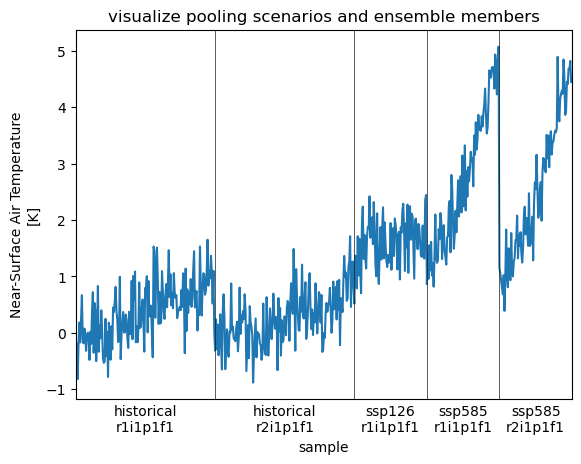

In [71]:
def visualize_pooling(data):

    mi = pd.MultiIndex.from_arrays([data["scenario"].values, data["member"].values])

    f, ax = plt.subplots()

    data.plot()

    xticks, xticklabels = [], []
    for i in mi.unique():

        loc = mi.get_loc(i)
        center = loc.start + (loc.stop - loc.start) / 2

        plt.axvline(loc.stop, color="0.1", lw=0.5)
        xticklabels.append("\n".join(i))
        xticks.append(center)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.xaxis.set_tick_params(length=0)
    ax.set_title("visualize pooling scenarios and ensemble members")
    ax.set_xlim(0, data.sample.size)


visualize_pooling(tas_pooled_y.tas.isel(gridcell=0))

## Calibration

With all the data preparation done we can now calibrate the different steps of MESMER-M. 

### Fit the harmonic model

First, we capture the seasonal cycle with a harmonic model. The coefficients of the model can vary with local annual mean temperature (fourier regression). This step removes the annual mean and determines the optimal order and the coefficients of the harmonic model: 
$$
T_{\text{mean response}}^{m,s,y} = \beta_{0,s} + \beta_{1,s} \cdot T_{s,y}
+ \sum_{i=1}^{n} \left[
g_{i,s}(T_{s,y}) \cdot \sin\left( \frac{i \pi (m \bmod 12 + 1)}{6} \right)
+ h_{i,s}(T_{s,y}) \cdot \cos\left( \frac{i \pi (m \bmod 12 + 1)}{6} \right)
\right]
$$,
where the subscripts y,m and s denote year, month and spatial location.

In [72]:
harmonic_model_fit = mesmer.stats.fit_harmonic_model(tas_pooled_y.tas, tas_pooled_m.tas)

harmonic_model_fit

<xarray.Dataset> Size: 7MB
Dimensions:         (gridcell: 118, coeff: 24, sample: 7056)
Coordinates:
    lat             (gridcell) float64 944B -49.5 -40.5 -31.5 ... 76.5 76.5 76.5
    lon             (gridcell) float64 944B 288.0 288.0 18.0 ... 324.0 342.0
  * coeff           (coeff) int64 192B 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23
    scenario        (sample) object 56kB 'historical' 'historical' ... 'ssp585'
    time            (sample) object 56kB 1850-01-16 12:00:00 ... 2100-12-16 1...
    member          (sample) <U8 226kB 'r1i1p1f1' 'r1i1p1f1' ... 'r2i1p1f1'
Dimensions without coordinates: gridcell, sample
Data variables:
    selected_order  (gridcell) int64 944B 3 3 3 2 2 3 3 4 3 ... 2 4 4 3 3 3 2 4
    coeffs          (gridcell, coeff) float64 23kB -0.04407 4.653 ... nan nan
    residuals       (sample, gridcell) float64 7MB -0.6276 -1.249 ... -1.833

### Approximate the residuals 

The harmonic model does not capture all of the variance in the signal. The residuals ($\eta_{m,s,y}$), computed as the difference between the monthly temperature data and the harmonic model predictions, are approximated using probabilistic sampling strategies. This process has two steps: (i) ensuring the residuals follow a Gaussian distribution by applying a power transformer, (ii) approximating the transformed residuals as a multivariate AR(1)-process with a localised covariance matrix


#### Train the power transformer

The residuals do no necessairly follow a gaussian distribution and might not be symmetric. Therefore, a Yeo-Johnson transformation is applied to map them onto a normal distribution:

$$
\Gamma_{\lambda}(\eta_{m,s,y}) =
\begin{cases}
\frac{(\eta_{m,s,y} + 1)^{\lambda} - 1}{\lambda} & \text{if } \eta_{m,s,y} \ge 0,\ \lambda \ne 0 \\\\[8pt]
\log(\eta_{m,s,y} + 1) & \text{if } \eta_{m,s,y} \ge 0,\ \lambda = 0 \\\\[8pt]
-\frac{(-\eta_{m,s,y} + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } \eta_{m,s,y} < 0,\ \lambda \ne 2 \\\\[8pt]
-\log(-\eta_{m,s,y} + 1) & \text{if } \eta_{m,s,y} < 0,\ \lambda = 2
\end{cases}
$$

The power transformer depends on a $\lambda$ parameter that defines the transform. Normally, $\lambda$ is constant, however, in Nath et al., [2022](https://esd.copernicus.org/articles/13/851/2022/) $\lambda$ is modelled with a logistic regression using local annual mean temperature as covariate:
$$
\lambda_{m,s,y} = \frac{2}{1 + \xi_{0,m,s} \cdot e^{\xi_{1,m,s} \cdot T_{s,y}}}
$$


 These two options are implementes as `"constant"` and `"logistic"`. We here use `"constant"` for performance reasons. 

In [73]:
# Original Nath. et al version:
# yj_transformer = mesmer.stats.YeoJohnsonTransformer("logistic")

yj_transformer = mesmer.stats.YeoJohnsonTransformer("constant")
pt_coefficients = yj_transformer.fit(tas_pooled_y.tas, harmonic_model_fit.residuals)

In [74]:
transformed_resids = yj_transformer.transform(
    tas_pooled_y.tas,
    harmonic_model_fit.residuals,
    pt_coefficients,
)

To illustrate the effect of the transform, we plot the skewness of the original and the transformed residuals:

Text(0.5, 1.0, 'Skewness of residuals')

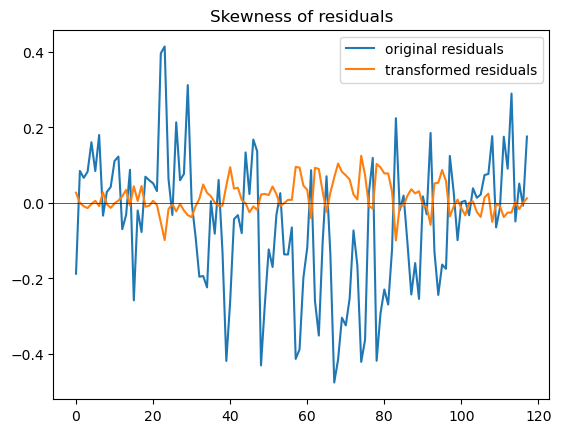

In [75]:
f, ax = plt.subplots()

ax.plot(
    sp.stats.skew(harmonic_model_fit.residuals, axis=0),
    label="original residuals",
)
ax.plot(
    sp.stats.skew(transformed_resids.transformed.T, axis=0),
    label="transformed residuals",
)

ax.axhline(0, lw=0.5, color="0.1")
ax.legend()
ax.set_title("Skewness of residuals")

#### Fit cyclo-stationary AR(1) process

The transformed monthly residuals ($\tilde{\eta}_{m,s,y}$) are now assumed to follow a cyclo-stationary AR(1) process, where the residuals in a given month depend on the residuals of the previous month and each month-to-month dependency has a distinct parameter: 
$$
\tilde{\eta}_{m,s,y} = \gamma_{0,m,s} + \gamma_{1,m,s} \cdot \tilde{\eta}_{m-1,s,y} + \nu_{m, s,y}, \\ \nu_{m, s,y} \sim \mathcal{N}(0, \Sigma_{\nu}(r))
$$

Because there is no previous timestep for the first one, we loose one time step of the residuals.

##### AR parameters

We first estimate the AR parameters through a regression

In [76]:
ar1_fit = mesmer.stats.fit_auto_regression_monthly(transformed_resids.transformed)
ar1_fit

<xarray.Dataset> Size: 7MB
Dimensions:    (month: 12, gridcell: 118, sample: 7055)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lat        (gridcell) float64 944B -49.5 -40.5 -31.5 ... 76.5 76.5 76.5
    lon        (gridcell) float64 944B 288.0 288.0 18.0 ... 306.0 324.0 342.0
    scenario   (sample) object 56kB 'historical' 'historical' ... 'ssp585'
    time       (sample) object 56kB 1850-02-15 00:00:00 ... 2100-12-16 12:00:00
    member     (sample) <U8 226kB 'r1i1p1f1' 'r1i1p1f1' ... 'r2i1p1f1'
Dimensions without coordinates: gridcell, sample
Data variables:
    slope      (month, gridcell) float64 11kB 0.1944 0.1468 ... -0.06053 0.08392
    intercept  (month, gridcell) float64 11kB -0.05807 -0.1008 ... 0.01933
    residuals  (gridcell, sample) float64 7MB -0.04294 0.1836 ... -2.449 -1.651

##### Find localized empirical covariance

For the covariance matrix of the white noise we first estimate the empirical covariance matrix of the gridcell's values and then localize it using the Gaspari-Cohn function. This function goes to 0 for for larger distances  and becomes exactly 0 for distances twice the so called localisation radius. This is also called regularization. It ensures that grid points that are further away from each other do not correlate. Such spurious correlations can arise from rank deficient covariance matrices. In our case because we estimate the covariance on data that has more gridcells than timesteps.

The localisation radius is a parameter that needs to be calibrated and we find the best localisation radius by cross-validation of several radii using the negative loglikelihood.

We determine the localized empirical spatial covariance for each month individually.

1. prepare the distance matrix, i.e., the distance between the gridpoints in km

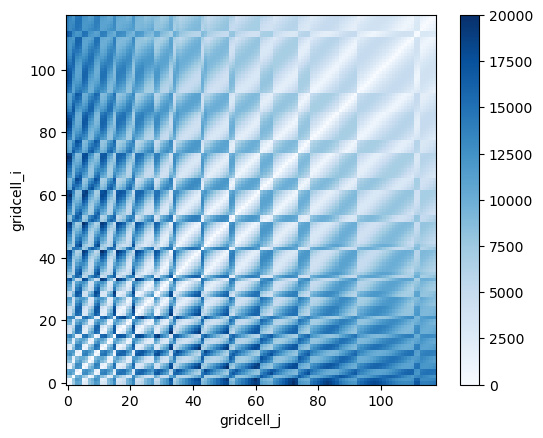

In [77]:
geodist = mesmer.geospatial.geodist_exact(tas_y.historical.lon, tas_y.historical.lat)

# plot
f, ax = plt.subplots()
geodist.plot(ax=ax, cmap="Blues")

ax.set_aspect("equal")

2. prepare the localizer(s) to regularize the covariance matrix

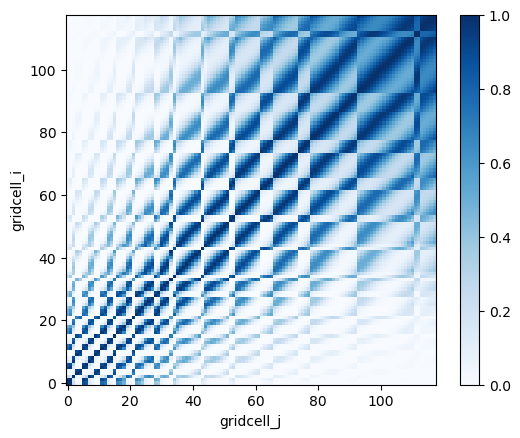

In [78]:
phi_gc_localizer = mesmer.stats.gaspari_cohn_correlation_matrices(
    geodist, localisation_radii=LOCALISATION_RADII
)
# plot one
f, ax = plt.subplots()
phi_gc_localizer[7500].plot(ax=ax, cmap="Blues")

ax.set_aspect("equal")

3. Compute the weights

In [79]:
weights = mesmer.weighted.equal_scenario_weights_from_datatree(tas_anoms_m)
weights = mesmer.datatree.pool_scen_ens(weights)

# because ar1_fit.residuals lost the first ts, we have to remove it here as well
weights = weights.isel(sample=slice(1, None))
weights

<xarray.Dataset> Size: 395kB
Dimensions:   (sample: 7055)
Coordinates:
    scenario  (sample) object 56kB 'historical' 'historical' ... 'ssp585'
    time      (sample) object 56kB 1850-02-15 00:00:00 ... 2100-12-16 12:00:00
    member    (sample) <U8 226kB 'r1i1p1f1' 'r1i1p1f1' ... 'r2i1p1f1' 'r2i1p1f1'
Dimensions without coordinates: sample
Data variables:
    weights   (sample) float64 56kB 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5

4. find the best localization radius and localize the empirical covariance matrix
    
    The more samples we pass to `find_localized_empirical_covariance_monthly`, the estimated localisation radius becomes larger. You may want to pass more `LOCALISATION_RADII` than we do here (however, the function warns if either the smallest or largest localisation radius is chosen).

In [80]:
dim = "time"
k_folds = 30

localized_ecov = mesmer.stats.find_localized_empirical_covariance_monthly(
    ar1_fit.residuals,
    weights.weights,
    phi_gc_localizer,
    dim=dim,
    k_folds=k_folds,
)

In [81]:
# TODO: Add a sentence on why the adjustmet is not necessary anymore

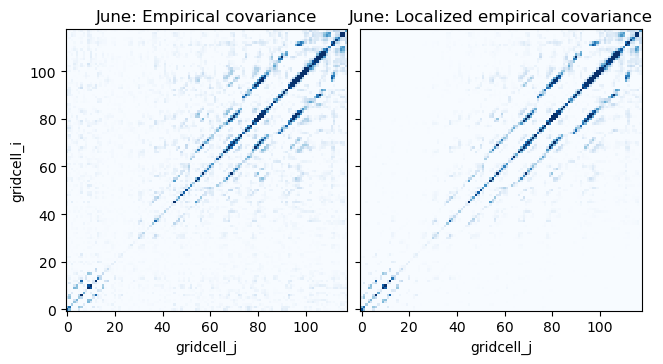

In [82]:
# plot the localized covariance matrix against the empirical covariance matrix for the month of June
month = 6

f, axs = plt.subplots(1, 2, sharey=True, constrained_layout=True)

opt = dict(vmin=0, vmax=1.5, cmap="Blues", add_colorbar=False)

ax = axs[0]
localized_ecov.sel(month=6).covariance.plot(ax=ax, **opt)
ax.set_aspect("equal")
ax.set_title("June: Empirical covariance")

ax = axs[1]
localized_ecov.sel(month=6).localized_covariance.plot(ax=ax, **opt)
ax.set_aspect("equal")
ax.set_title("June: Localized empirical covariance")
ax.set_ylabel("")
plt.show()

## Saving the parameters

Finally, we have calibrated all needed parameters and can save them. We can use filefisher to nicely create file names and save the parameters.

In [83]:
# define path relative to this notebook & create folder
param_path = pathlib.Path("./output/calibrated_parameters/mesmer-m/")

#### Create time coordinate
We overwrote the time coordinate with 'sample'. Thus, we need to get the original time coordinate to be able to validate our results later on. If it is not needed to align the final emulations with the original data, this can be omitted, the time coordinates can later be generated for example with 

```python
monthly_time = xr.cftime_range("1850-01-01", "2100-12-31", freq="MS", calendar="gregorian")
monthly_time = xr.DataArray(monthly_time, dims="time", coords={"time": monthly_time})
```

In [84]:
hist_time = tas_m.historical.time
scen_time = tas_m.ssp585.time
m_time = xr.concat([hist_time, scen_time], dim="time")

#### Store data for all modules

In [86]:
PARAM_FILEFINDER = filefisher.FileFinder(
    path_pattern=param_path / "{esm}_{scen}",
    file_pattern="params_{module}_{esm}_{scen}.nc",
)

scen_str = "-".join(scenarios)

folder = PARAM_FILEFINDER.create_path_name(esm=model, scen=scen_str)
pathlib.Path(folder).mkdir(exist_ok=True, parents=True)

params = {
    "harmonic-model": harmonic_model_fit,
    "power-transformer": pt_coefficients,
    "local-variability": ar1_fit,
    "covariance": localized_ecov,
    "grid-orig": grid_orig,
    "m-time": m_time,
}

save_files = True  # we don't save them here in the example
if save_files:

    for module, param in params.items():

        filename = PARAM_FILEFINDER.create_full_name(
            module=module,
            esm=model,
            scen=scen_str,
        )

        param.to_netcdf(filename)